#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Solve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with the Fourier serie. How many terms in the fourier serie are necessary to obtain a $\text{tol}=10^{-3}$?

#### **Exercise 2**: FDM for oppen boundaries (optional)

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="300" height="400" />

In [45]:
#Librery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time as time
import sympy as sp

##Ejercicio 1:

Solucion a la ecuacion

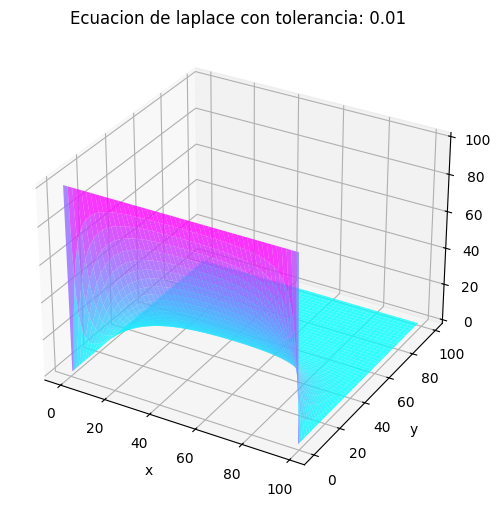

Con esta tolerancia se hicieron 577 iteraciones con un tiempo de 8.231350183486938 s


In [46]:
Nmax, tol = 100 , 1e-2 #tolerancia de 1e-2

V = np.zeros((Nmax,Nmax),float)

for i in range(Nmax):
  V[i,0] = 100

####Laplace-funcionando con tolerancia#####
inicio = time.time()
V_diff = 1
V0 = V.copy()
lista = []
inicio = time.time()

while V_diff > tol:
  for i in range(1, Nmax-1):
    for j in range(1,Nmax-1):
      V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

  V_diff = np.abs(np.mean(V)-np.mean(V0))
  V0 = V.copy()
  lista.append(V_diff)

fin = time.time()
tiempo = fin-inicio



##### Grafica ######
x = np.arange(0,Nmax,1)
y = x
X, Y = np.meshgrid(x,y)
Z = V[X,Y]

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)

ax.set_title(f"Ecuacion de laplace con tolerancia: {tol} ")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

print(f"Con esta tolerancia se hicieron {len(lista)} iteraciones con un tiempo de {tiempo} s")

Comparacion con la serie de fourier

In [47]:
##solucion por serie de fourier
def un(x,y,n=1,L=1):
  v0 = 100
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

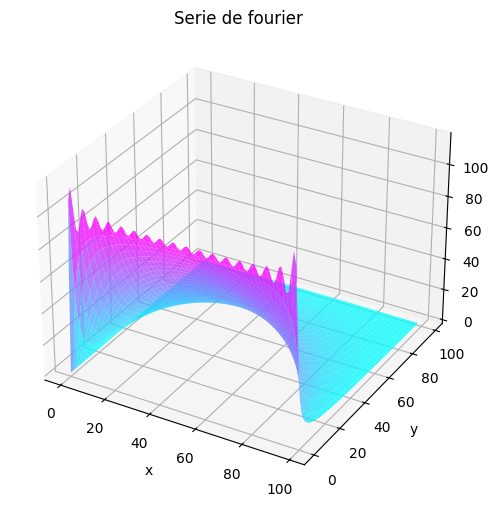

En comparacion con el metodo de diferencias finitas, la serie de fouries alcanza la tolerancia a las 38 iteraciones y se demora 0.3268139362335205 s


In [62]:
L = 100
coordx = np.arange(0,L,1)
coordy = coordx
x1 , y1 = np.meshgrid(coordx, coordy, indexing= 'ij')
tol_f = 1e-3
z1 = 0

N = 2
un_diff = 1
z0 = 0
lista_f = []
inicio_f = time.time()
while un_diff > tol_f:
  for n in range(1,N,2): #Only odd n values
    z1 += un(x1,y1,n,L)
  N += 2
  un_diff = np.abs(np.mean(z1)-np.mean(z0))
  lista_f.append(un_diff)
  z0 = z1
  if un_diff > tol_f:
    z1 = 0
final_f = time.time()
tiempo_f = final_f-inicio_f

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(x1, y1, z1, cmap='cool', alpha=0.8)

ax.set_title("Serie de fourier ")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

print(f"En comparacion con el metodo de diferencias finitas, la serie de fouries alcanza la tolerancia a las {N} terminos y se demora {tiempo_f} s")

La serie de fourier es muchosimo mas rapida y requiere menos iteraciones que el metodo de diferencias finitas con una tolerancia, aunque la exactitud en las fronteras puede discutirse mas.

## Ejercicio 2

Solucion numerica

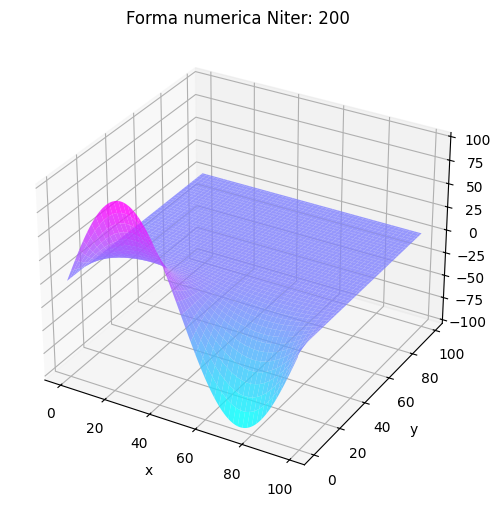

In [50]:
N_max, Niter = 100 , 200
x_s = np.arange(0,N_max,1)
y_s = x_s

V_i = np.zeros((N_max,N_max),float)

def fron(V,x,y,N_max):
  u0 = 100
  for i in range(N_max):
    V[i,0] = u0*np.sin((2*np.pi)*x_s[i]/N_max)

  return V

V_s = fron(V_i,x_s,y_s,N_max)

X_sin ,Y_sin = np.meshgrid(x_s,y_s)

V_difs = 1
V0_s = V_s.copy()
lista_s = []

for iter in range(Niter):
  for i in range(1, N_max-1):
    for j in range(1,N_max-1):
      V_s[i,j] = 0.25*(V_s[i+1,j]+V_s[i-1,j]+V_s[i,j+1]+V_s[i,j-1])


Z_sin = V_s[X_sin,Y_sin]

##### Grafica ######
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X_sin, Y_sin, Z_sin, cmap='cool', alpha=0.8)

ax.set_title(f"Forma numerica Niter: {Niter} ")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Solucion analitica

In [51]:
x_ = sp.Symbol("x")
y_ = sp.Symbol("y")

U = sp.Function("U")(x_,y_)

laplace_eq = sp.Eq(U.diff(x_,x_)+ U.diff(y_,y_),0)

#Queremos resolver analiticamente la ecuacion de laplace
laplace_eq

Eq(Derivative(U(x, y), (x, 2)) + Derivative(U(x, y), (y, 2)), 0)

In [52]:
#aplicamos separacion de varibale
ux = sp.Function("X")(x_)
uy = sp.Function("Y")(y_)
a = sp.Symbol("a")

Ux = sp.Eq(ux.diff(x_,x_)+(a**2)*ux,0)
Uy = sp.Eq(uy.diff(y_,y_)-(a**2)*uy,0)

Ux

Eq(a**2*X(x) + Derivative(X(x), (x, 2)), 0)

In [53]:
Uy

Eq(-a**2*Y(y) + Derivative(Y(y), (y, 2)), 0)

In [54]:
#solucionando las ecuaciones

Ux_sol = sp.dsolve(Ux)
Uy_sol = sp.dsolve(Uy)

Ux_sol

Eq(X(x), C1*exp(-I*a*x) + C2*exp(I*a*x))

In [55]:
Uy_sol

Eq(Y(y), C1*exp(-a*y) + C2*exp(a*y))

La solucion general es:

$$U(x,y) = X(x)Y(y) = (C_1Sin(ax)+C_2Cos(ax))(C_3e^{-ay}+C_4e^{ay})$$

Aplicando las condiciones de frontera dadas:

$$U(x,0) = u_0Sin(\frac{2 \pi x}{L})$$
$$U(0,y) = 0$$
$$U(L,y) = 0$$
$$U(x,\infty) = 0$$

Obtenemos que
$$C_2 = 0 ,  C_4 = 0 $$
$$a = \frac{n\pi}{L}$$

Y obtendriamos la solucion

$$U(x,y) = \sum_{n = 0}^{\infty} u_0 Sin(\frac{n\pi x}{L})e^{-\frac{n\pi y}{L}} $$

In [56]:
#Con la ultima condicion de frontera
u0 = sp.Symbol("u0")
L = sp.Symbol("L")
sol = sp.Eq(U,u0*sp.sin(2*sp.pi*x_/L)*sp.exp(-2*sp.pi*y_/L))
sol

Eq(U(x, y), u0*exp(-2*pi*y/L)*sin(2*pi*x/L))

In [58]:
sol_ = u0*sp.sin(2*sp.pi*x_/L)*sp.exp(-1*2*sp.pi*y_/L)

f = sp.lambdify((x_,y_,L,u0),sol_)

In [59]:
#graficando
x_n = np.arange(0,100,1)
y_n = x_n

X_n ,Y_n = np.meshgrid(x_n,y_n)

z_n = f(X_n,Y_n,100,100)

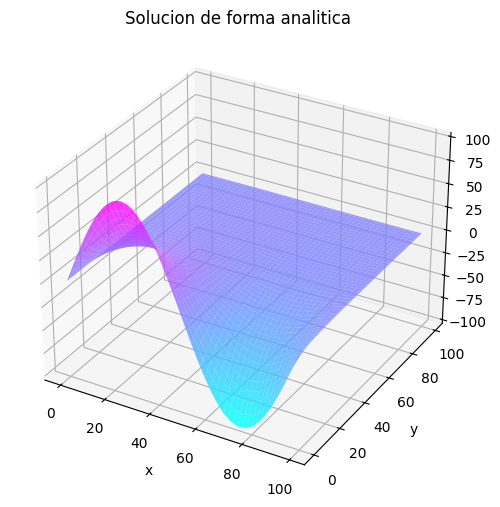

In [61]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X_n, Y_n, z_n, cmap='cool', alpha=0.8)

ax.set_title(f"Solucion de forma analitica ")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()